In [1]:
import pandas as pd
import numpy as np
#from scipy.stats import gaussian_kde

# 3.7.1 for Kaggle compatibility
import matplotlib.pyplot as plt

# 1.2.2 for Kaggle compatibility
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report


In [2]:
df = pd.read_csv("Diabetes Health Indicators.csv")

In [3]:
df.head()

,DIABETE4,DIABTYPE,_RFHYPE6,_RFCHOL3,_CHOLCH3,_BMI5,SMOKE100,CVDSTRK3,_MICHD,EXERANY2,PRIMINS1,MEDCOST1,GENHLTH,MENTHLTH,PHYSHLTH,DIFFWALK,_SEX,_AGEG5YR,_EDUCAG,_INCOMG1
0,1,NaN,2,1.0,1,3047.0,2.0,2,2.0,2,3,2,2,88,88,1.0,2.0,13.0,3.0,9.0
1,3,NaN,2,2.0,1,2856.0,2.0,2,2.0,1,3,2,2,88,88,2.0,2.0,13.0,3.0,9.0
2,3,NaN,2,2.0,1,2231.0,1.0,2,2.0,1,3,1,4,2,6,1.0,2.0,13.0,2.0,1.0
3,3,NaN,1,1.0,1,2744.0,2.0,2,2.0,1,3,2,2,88,2,1.0,2.0,12.0,3.0,9.0
4,1,NaN,2,1.0,1,2585.0,2.0,2,2.0,1,3,2,4,88,88,1.0,2.0,12.0,3.0,5.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117666 entries, 0 to 117665
Data columns (total 20 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   DIABETE4  117666 non-null  int64  
 1   DIABTYPE  6372 non-null    float64
 2   _RFHYPE6  117666 non-null  int64  
 3   _RFCHOL3  103494 non-null  float64
 4   _CHOLCH3  117666 non-null  int64  
 5   _BMI5     106527 non-null  float64
 6   SMOKE100  111972 non-null  float64
 7   CVDSTRK3  117666 non-null  int64  
 8   _MICHD    116364 non-null  float64
 9   EXERANY2  117666 non-null  int64  
 10  PRIMINS1  117666 non-null  int64  
 11  MEDCOST1  117666 non-null  int64  
 12  GENHLTH   117666 non-null  int64  
 13  MENTHLTH  117666 non-null  int64  
 14  PHYSHLTH  117666 non-null  int64  
 15  DIFFWALK  112980 non-null  float64
 16  _SEX      117665 non-null  float64
 17  _AGEG5YR  117665 non-null  float64
 18  _EDUCAG   117665 non-null  float64
 19  _INCOMG1  117665 non-null  float64
dtypes: f

In [5]:
df.describe()

,DIABETE4,DIABTYPE,_RFHYPE6,_RFCHOL3,_CHOLCH3,_BMI5,SMOKE100,CVDSTRK3,_MICHD,EXERANY2,PRIMINS1,MEDCOST1,GENHLTH,MENTHLTH,PHYSHLTH,DIFFWALK,_SEX,_AGEG5YR,_EDUCAG,_INCOMG1
count,117666.000000,6372.000000,117666.000000,103494.000000,117666.000000,106527.000000,111972.000000,117666.000000,116364.000000,117666.000000,117666.000000,117666.000000,117666.000000,117666.000000,117666.000000,112980.000000,117665.000000,117665.000000,117665.000000,117665.000000
mean,2.754407,2.351381,1.442677,1.490231,1.623018,2819.737391,1.652913,1.976059,1.915919,1.258137,11.552853,1.926053,2.638834,58.225401,58.457600,1.858550,1.529359,7.834352,3.088735,5.429100
std,0.757814,1.449958,0.711739,0.852735,1.908260,644.914806,0.686792,0.387274,0.277510,0.544234,25.663391,0.437576,1.092192,37.921019,37.703563,0.527444,0.499139,3.733861,1.057099,2.318721
min,1.000000,1.000000,1.000000,1.000000,1.000000,1202.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.000000,1.000000,1.000000,1.000000,2378.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,12.000000,14.000000,2.000000,1.000000,5.000000,2.000000,4.000000
50%,3.000000,2.000000,1.000000,1.000000,1.000000,2720.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,3.000000,88.000000,88.000000,2.000000,2.000000,8.000000,3.000000,5.000000
75%,3.000000,2.000000,2.000000,2.000000,1.000000,3128.000000,2.000000,2.000000,2.000000,1.000000,5.000000,2.000000,3.000000,88.000000,88.000000,2.000000,2.000000,11.000000,4.000000,7.000000
max,9.000000,9.000000,9.000000,9.000000,9.000000,9979.000000,9.000000,9.000000,2.000000,9.000000,99.000000,9.000000,9.000000,99.000000,99.000000,9.000000,2.000000,14.000000,9.000000,9.000000


In [6]:
df.nunique()

,0
DIABETE4,6
DIABTYPE,4
_RFHYPE6,3
_RFCHOL3,3
_CHOLCH3,4
_BMI5,3122
SMOKE100,4
CVDSTRK3,4
_MICHD,2
EXERANY2,4


In [7]:
#Handling Missing Values
df.isnull().sum()


,0
DIABETE4,0
DIABTYPE,111294
_RFHYPE6,0
_RFCHOL3,14172
_CHOLCH3,0
_BMI5,11139
SMOKE100,5694
CVDSTRK3,0
_MICHD,1302
EXERANY2,0


In [9]:
df.drop(columns=['DIABTYPE'], inplace=True)


In [10]:
df = df[df['DIABETE4'].isin([1, 2])]
df['target'] = df['DIABETE4'].map({1: 1, 2: 0})
df.drop(columns=['DIABETE4'], inplace=True)


In [11]:
binary_cols = ['_RFCHOL3', 'SMOKE100', '_MICHD', 'DIFFWALK']

for col in binary_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-514202554.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [12]:
df['_BMI5'].fillna(df['_BMI5'].median(), inplace=True)


/tmp/ipython-input-2440246119.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['_BMI5'].fillna(df['_BMI5'].median(), inplace=True)


In [13]:
demo_cols = ['_SEX', '_AGEG5YR', '_EDUCAG', '_INCOMG1']

for col in demo_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-2271458575.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
df.isnull().sum()


,0
_RFHYPE6,0
_RFCHOL3,0
_CHOLCH3,0
_BMI5,0
SMOKE100,0
CVDSTRK3,0
_MICHD,0
EXERANY2,0
PRIMINS1,0
MEDCOST1,0


In [15]:
# duplicates
print("Duplicates:", df.duplicated().sum())
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Dropped duplicates, new shape:", df.shape)


Duplicates: 8
Dropped duplicates, new shape: (16961, 19)


In [16]:
#Encoding
binary_cols = [
    '_RFHYPE6', '_RFCHOL3', '_CHOLCH3', 'SMOKE100',
    'CVDSTRK3', '_MICHD', 'EXERANY2', 'PRIMINS1',
    'MEDCOST1', 'DIFFWALK'
]

for col in binary_cols:
    df[col] = df[col].astype(int)


In [17]:
#Ordinal Features
ordinal_cols = ['GENHLTH', '_AGEG5YR', '_EDUCAG', '_INCOMG1']

for col in ordinal_cols:
    df[col] = df[col].astype(int)


In [19]:
#Outliers
num_cols = ['_BMI5', 'MENTHLTH', 'PHYSHLTH']
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df


In [20]:
df = remove_outliers_iqr(df, num_cols)


In [22]:
df.describe()


,_RFHYPE6,_RFCHOL3,_CHOLCH3,_BMI5,SMOKE100,CVDSTRK3,_MICHD,EXERANY2,PRIMINS1,MEDCOST1,GENHLTH,MENTHLTH,PHYSHLTH,DIFFWALK,_SEX,_AGEG5YR,_EDUCAG,_INCOMG1,target
count,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000,16336.000000
mean,1.739594,1.717311,1.322968,3024.739410,1.604922,1.925992,1.808337,1.404016,9.547625,1.929052,3.263773,60.451457,51.427155,1.704089,1.531893,9.617960,2.892630,5.080436,0.948396
std,0.668053,0.846771,1.505017,541.690461,0.668783,0.457132,0.393621,0.613165,22.161188,0.428890,1.042659,36.631381,37.307857,0.646413,0.498997,2.718918,1.069592,2.501182,0.221233
min,1.000000,1.000000,1.000000,1560.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000,2657.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,3.000000,18.000000,10.000000,1.000000,1.000000,8.000000,2.000000,3.000000,1.000000
50%,2.000000,2.000000,1.000000,2999.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,3.000000,88.000000,77.000000,2.000000,2.000000,10.000000,3.000000,5.000000,1.000000
75%,2.000000,2.000000,1.000000,3344.000000,2.000000,2.000000,2.000000,2.000000,5.000000,2.000000,4.000000,88.000000,88.000000,2.000000,2.000000,12.000000,4.000000,6.000000,1.000000
max,9.000000,9.000000,9.000000,4526.000000,9.000000,9.000000,2.000000,9.000000,99.000000,9.000000,9.000000,99.000000,99.000000,9.000000,2.000000,14.000000,9.000000,9.000000,1.000000


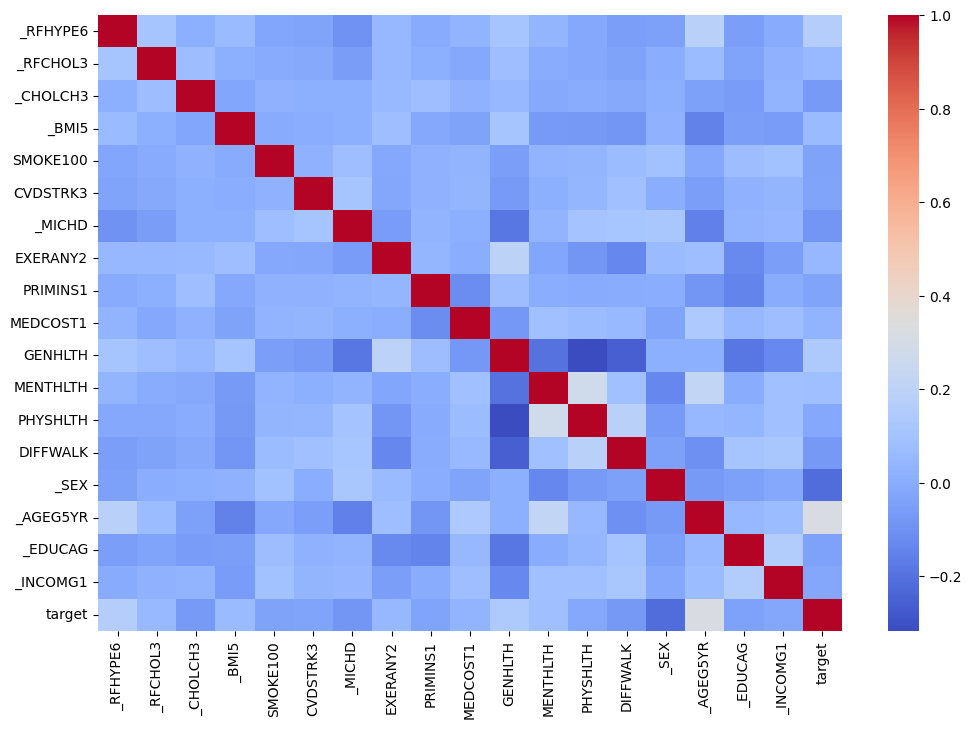

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.show()


In [24]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.set(style="whitegrid")


<Figure size 600x400 with 0 Axes>

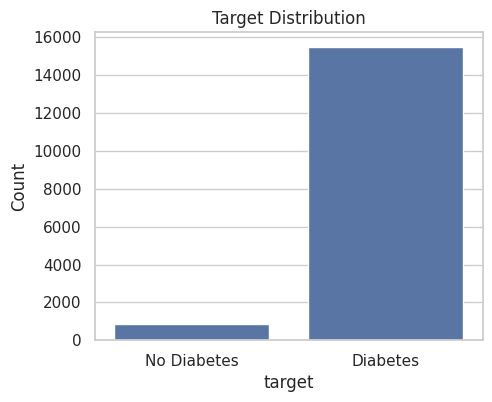

In [26]:
#Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.title('Target Distribution')
plt.ylabel('Count')
plt.show()


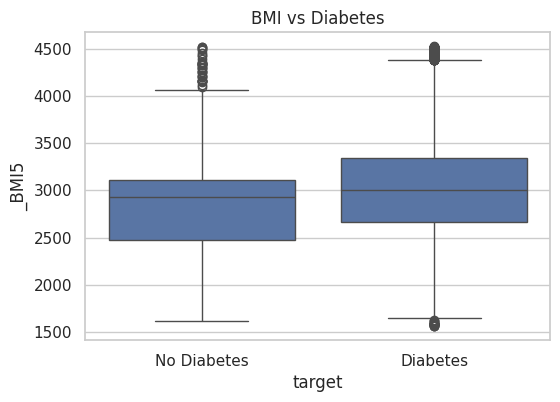

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='_BMI5', data=df)
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.title('BMI vs Diabetes')
plt.show()


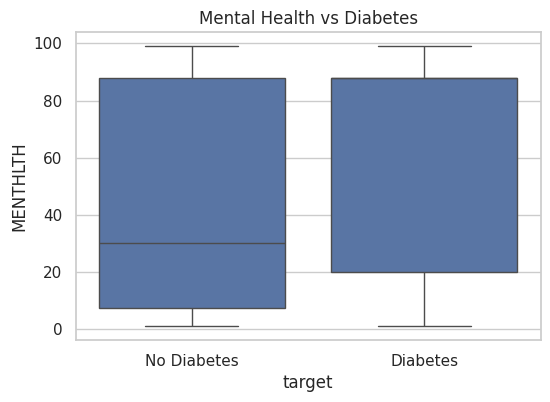

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='MENTHLTH', data=df)
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.title('Mental Health vs Diabetes')
plt.show()


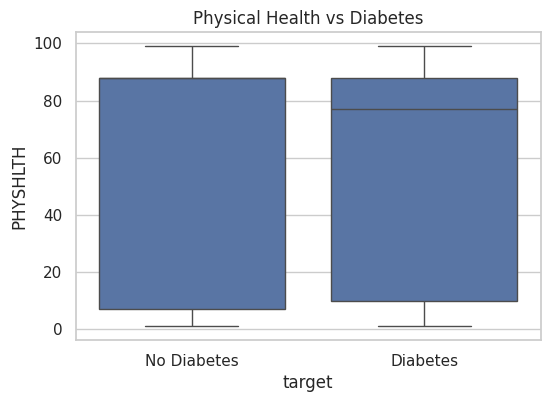

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='PHYSHLTH', data=df)
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.title('Physical Health vs Diabetes')
plt.show()


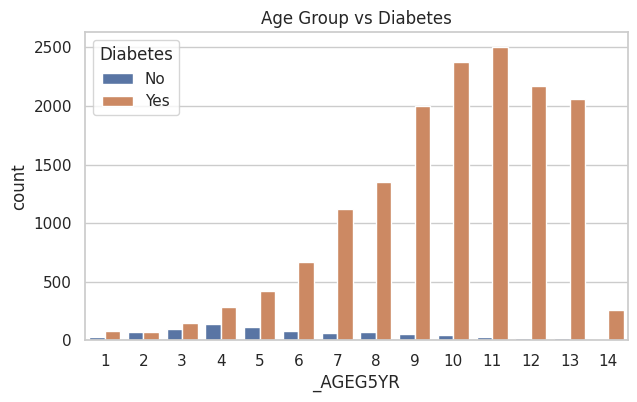

In [30]:
plt.figure(figsize=(7,4))
sns.countplot(x='_AGEG5YR', hue='target', data=df)
plt.title('Age Group vs Diabetes')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.show()


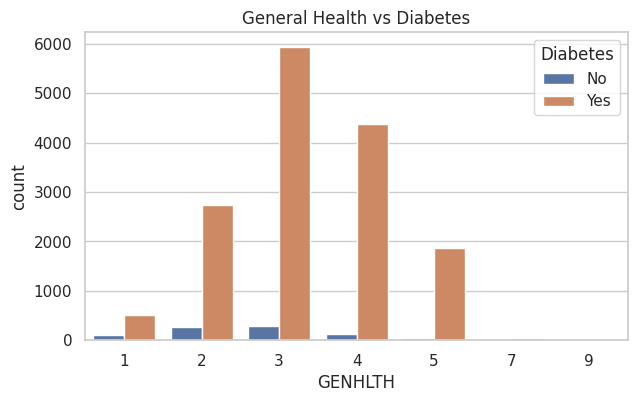

In [34]:
plt.figure(figsize=(7,4))
sns.countplot(x='GENHLTH', hue='target', data=df)
plt.title('General Health vs Diabetes')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.show()


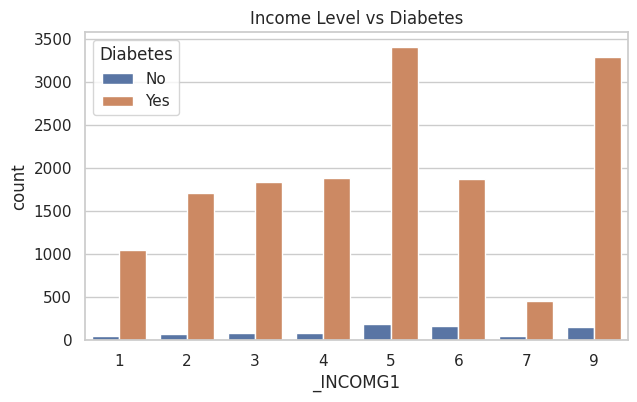

In [33]:
plt.figure(figsize=(7,4))
sns.countplot(x='_INCOMG1', hue='target', data=df)
plt.title('Income Level vs Diabetes')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.show()


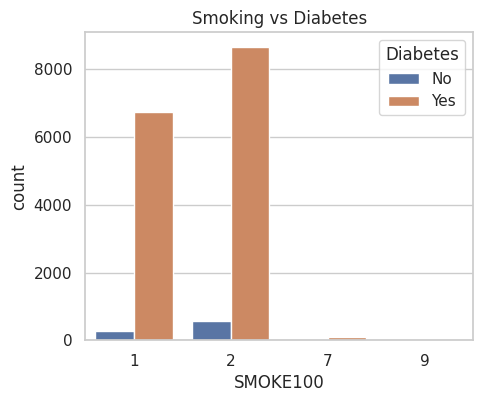

In [31]:
plt.figure(figsize=(5,4))
sns.countplot(x='SMOKE100', hue='target', data=df)
plt.title('Smoking vs Diabetes')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.show()


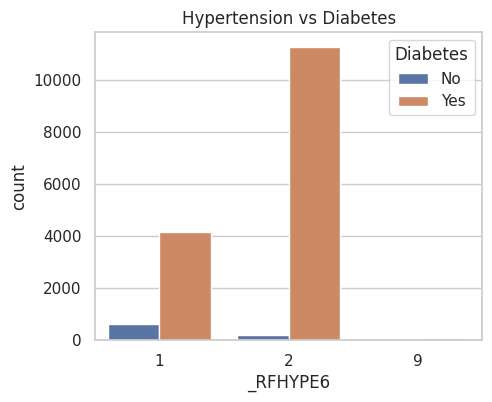

In [32]:
plt.figure(figsize=(5,4))
sns.countplot(x='_RFHYPE6', hue='target', data=df)
plt.title('Hypertension vs Diabetes')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.show()


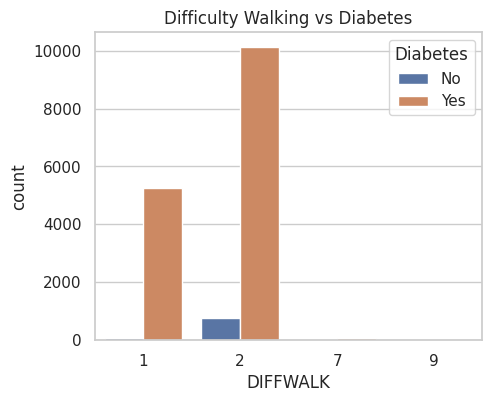

In [35]:
plt.figure(figsize=(5,4))
sns.countplot(x='DIFFWALK', hue='target', data=df)
plt.title('Difficulty Walking vs Diabetes')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.show()


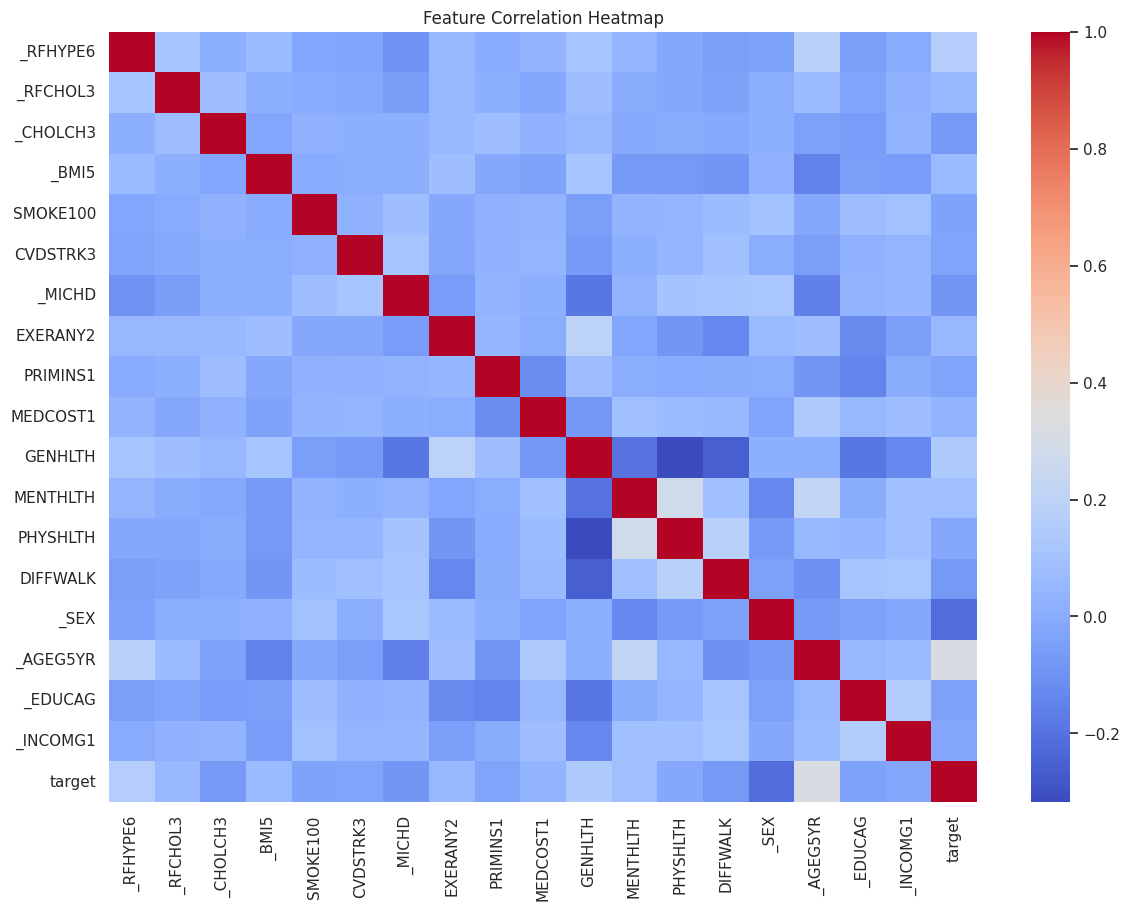

In [36]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


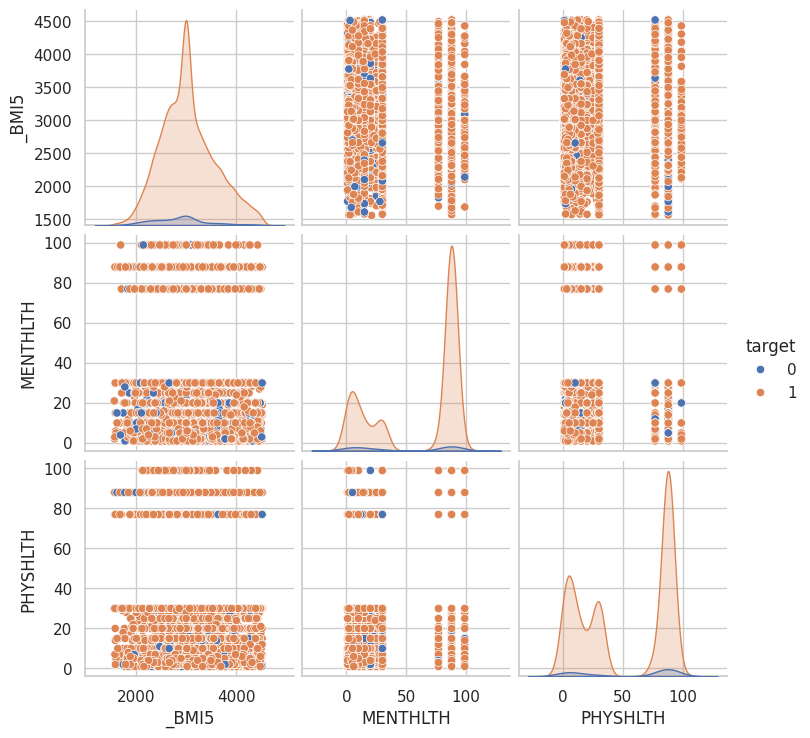

In [37]:
sns.pairplot(
    df[['target', '_BMI5', 'MENTHLTH', 'PHYSHLTH']],
    hue='target',
    diag_kind='kde'
)
plt.show()


In [38]:

#log transformation
import numpy as np

skewed_cols = ['_BMI5', 'MENTHLTH', 'PHYSHLTH']

for col in skewed_cols:
    df[col] = np.log1p(df[col])   # log(1+x)


In [39]:
#Scaling & split data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [40]:
#logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))


Logistic Regression
              precision    recall  f1-score   support

           0       0.22      0.89      0.36       169
           1       0.99      0.83      0.90      3099

    accuracy                           0.83      3268
   macro avg       0.61      0.86      0.63      3268
weighted avg       0.95      0.83      0.88      3268

ROC-AUC: 0.9416074282408335


In [41]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest
              precision    recall  f1-score   support

           0       0.64      0.34      0.45       169
           1       0.97      0.99      0.98      3099

    accuracy                           0.96      3268
   macro avg       0.80      0.67      0.71      3268
weighted avg       0.95      0.96      0.95      3268

ROC-AUC: 0.9337742085154401


In [42]:
#XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


XGBoost
              precision    recall  f1-score   support

           0       0.36      0.76      0.49       169
           1       0.99      0.93      0.96      3099

    accuracy                           0.92      3268
   macro avg       0.67      0.84      0.72      3268
weighted avg       0.95      0.92      0.93      3268

ROC-AUC: 0.9425487511718802


In [43]:
#deep model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [44]:
#build model
dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
#Training
history = dl_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    class_weight={0:1, 1: (y_train==0).sum()/(y_train==1).sum()},
    verbose=1
)


Epoch 1/30
327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6854 - auc: 0.7314 - loss: 0.0611 - val_accuracy: 0.8386 - val_auc: 0.9261 - val_loss: 0.3875
Epoch 2/30
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8289 - auc: 0.9133 - loss: 0.0387 - val_accuracy: 0.8447 - val_auc: 0.9325 - val_loss: 0.3634
Epoch 3/30
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8317 - auc: 0.9298 - loss: 0.0359 - val_accuracy: 0.8386 - val_auc: 0.9304 - val_loss: 0.3632
Epoch 4/30
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8249 - auc: 0.9220 - loss: 0.0371 - val_accuracy: 0.8416 - val_auc: 0.9318 - val_loss: 0.3647
Epoch 5/30
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8275 - auc: 0.9247 - loss: 0.0371 - val_accuracy: 0.8516 - val_auc: 0.9322 - val_loss: 0.3499
Epoch 6/30
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8436 - auc: 0.9389 - loss: 0.0325 - val_accuracy: 0.8405 - val_auc: 0.9344 - val_loss: 0.3689
Epoch 7/30
327/327 ━━━━━━━━━━━━━━━━━━━━ 

In [46]:
#Evaluation
dl_model.evaluate(X_test_scaled, y_test)

y_prob_dl = dl_model.predict(X_test_scaled)
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dl))


103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8427 - auc: 0.9189 - loss: 0.3495
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ROC-AUC: 0.9313578917421347


In [47]:
#Find Best Model
import pandas as pd
from sklearn.metrics import roc_auc_score, recall_score, f1_score
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Deep Learning'],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_dl)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, (y_prob_dl > 0.5).astype(int))
    ],
    'F1': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, (y_prob_dl > 0.5).astype(int))
    ]
})

results.sort_values(by='ROC_AUC', ascending=False)


,Model,ROC_AUC,Recall,F1
2,XGBoost,0.942549,0.926105,0.955075
0,Logistic Regression,0.941607,0.829622,0.904008
1,Random Forest,0.933774,0.989674,0.977218
3,Deep Learning,0.931358,0.849306,0.915001


In [48]:
from sklearn.ensemble import RandomForestClassifier

X_full = df.drop(columns='target')
y_full = df['target']

best_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # مهم بسبب Imbalance
    random_state=42
)

best_model.fit(X_full, y_full)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [49]:
#save models
import joblib

joblib.dump(best_model, 'best_diabetes_rf_model.pkl')


['best_diabetes_rf_model.pkl']

In [50]:
#save scaling
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']